Import the libraries for Data Cleaning / Visualization / Lazy Predict / SKLearn

In [ ]:
# Libraries for data cleaning/visualization
import pandas as pd
pd.set_option("display.max_columns", 100)
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt

# Lazy predict for an initial guide
!pip install lazypredict
import lazypredict
from lazypredict.Supervised import LazyClassifier

# Import sklearn libraries
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import LinearSVC

Import Telco DataSet

In [ ]:
# Initial Dataframe
df = pd.read_csv('https://raw.githubusercontent.com/carlosfab/dsnp2/master/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv')

## Main infos about shape and nulls
print(f"Total lines: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}\n")

# Print the dataframe
df.head(10)

# By passing the show_counts as true, we visualize that there are not null values
df.info(show_counts=True)
df

Total lines: 7043
Total columns: 21

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paper

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


Visualize Data

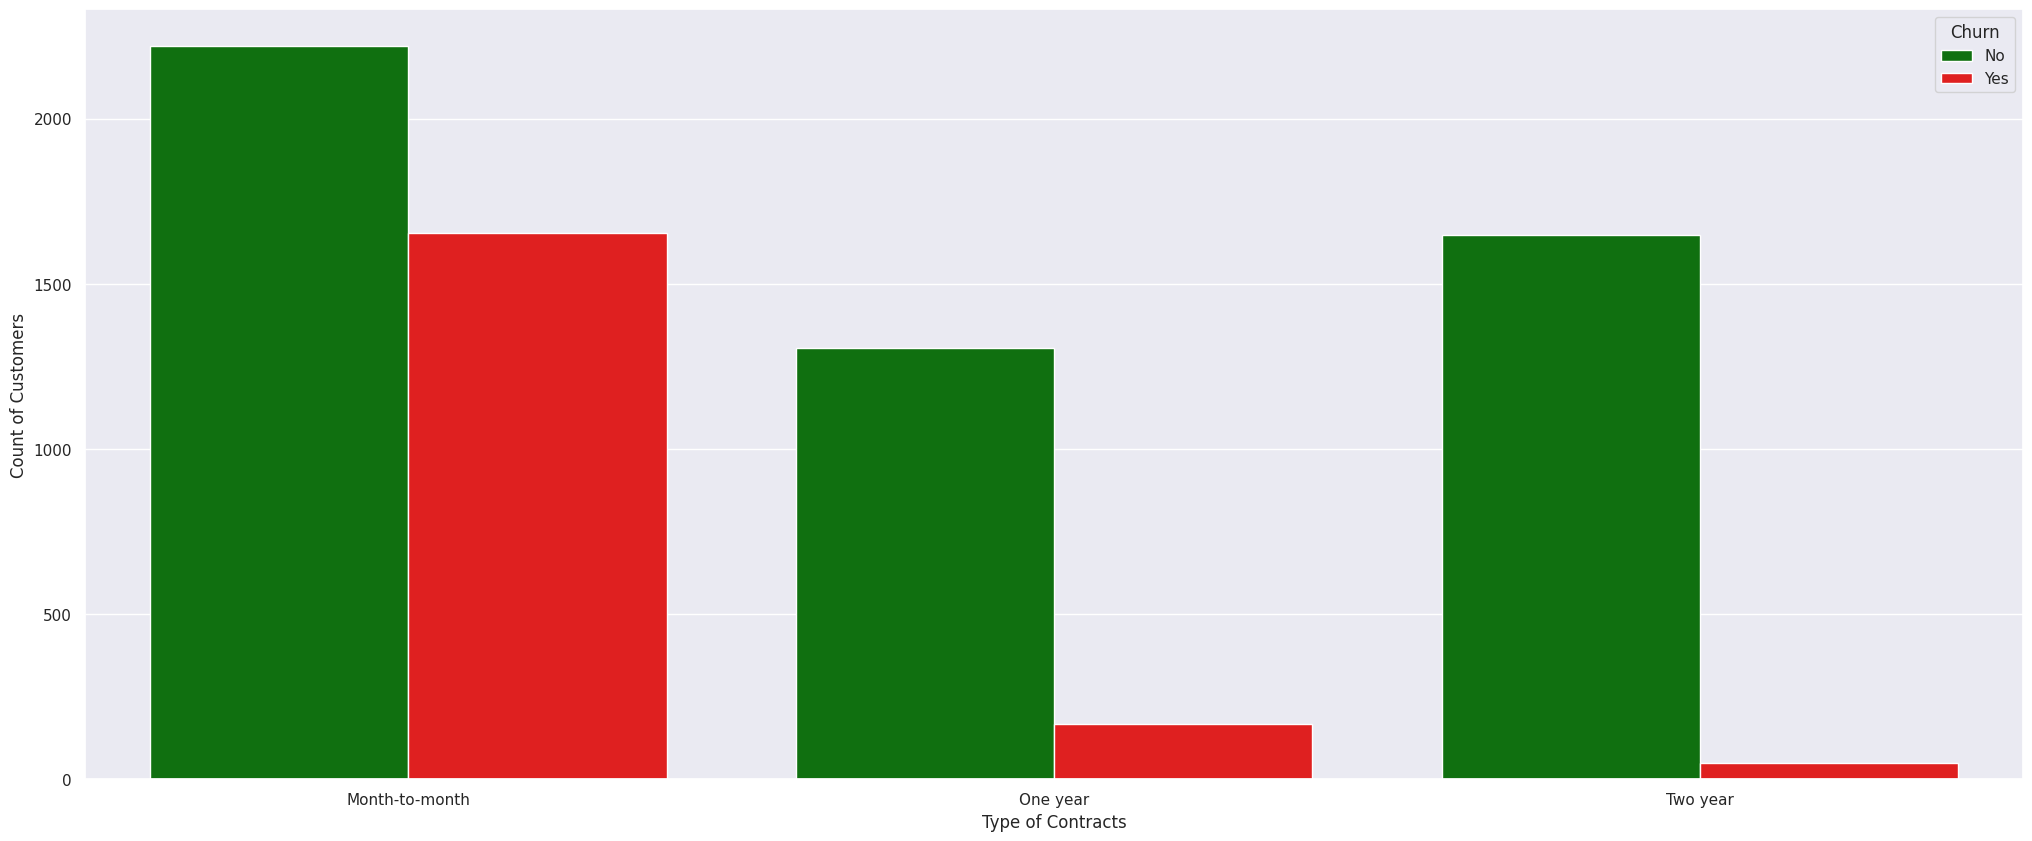

In [ ]:
# sns plot for churn using type of contract

sns.countplot(x = 'Contract', hue = 'Churn', data = df, palette = {'Yes': 'red', 'No': 'green'})
plt.ylabel('Count of Customers')
plt.xlabel('Type of Contracts')
plt.show()


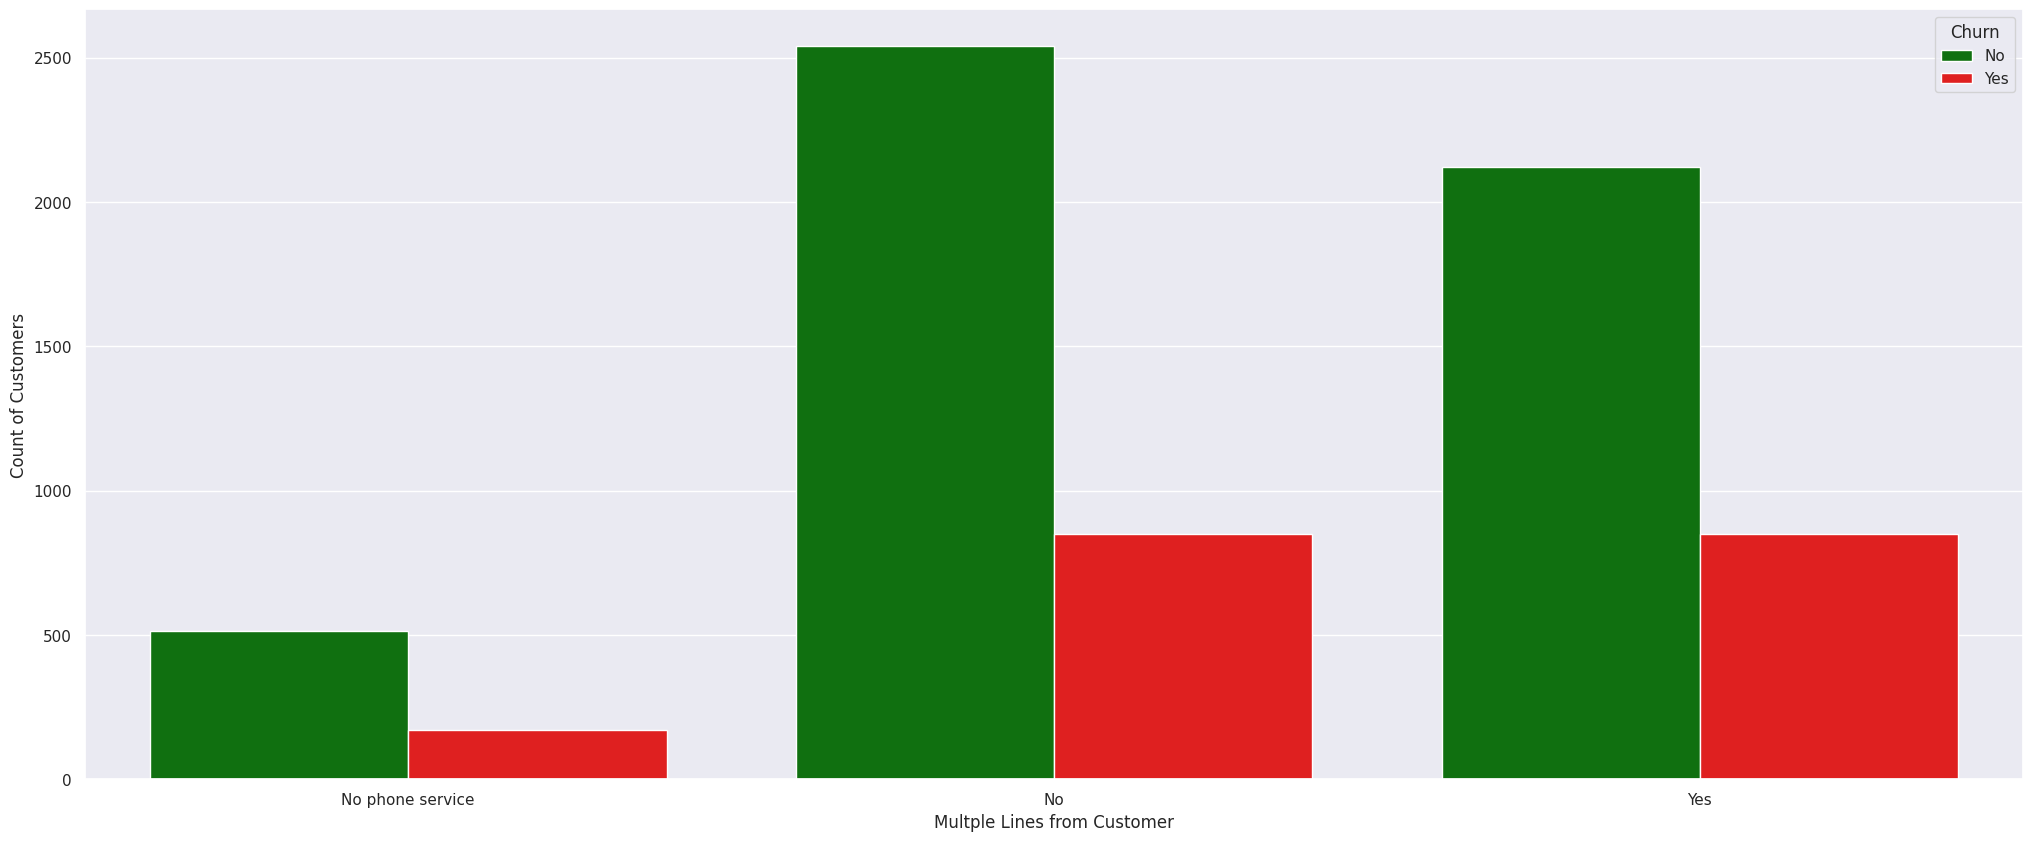

In [ ]:
# sns plot for churn using multiple lines where y-axis name is count of customers

sns.countplot(x = 'MultipleLines', hue = 'Churn', data = df, palette = {'Yes': 'red', 'No': 'green'})
plt.ylabel('Count of Customers')
plt.xlabel('Multple Lines from Customer')
plt.show()


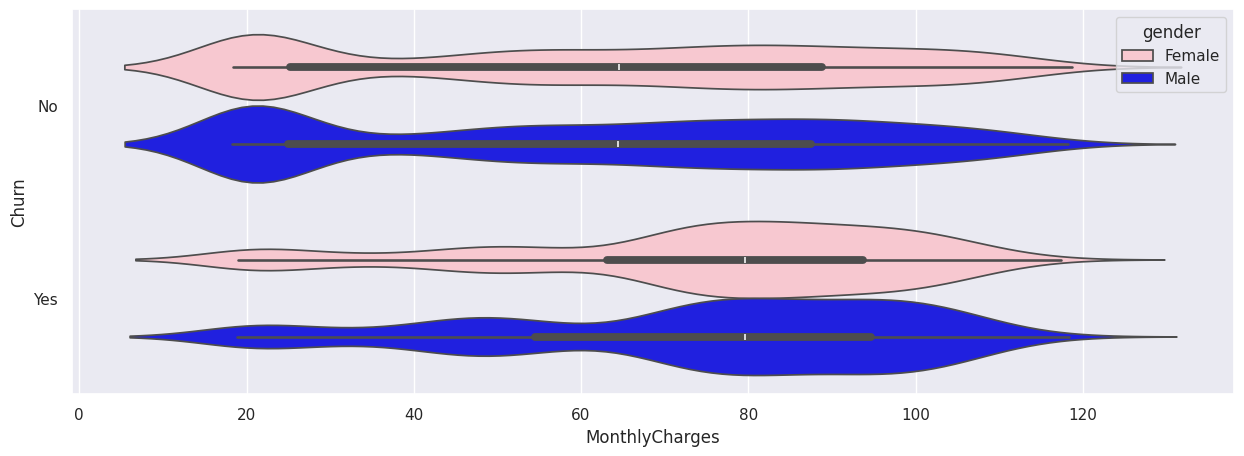

In [ ]:
# sns violin plot using gender and monthlycharges and churn shown sideways
sns.set(rc={'figure.figsize':(15,5)})
sns.violinplot(x = "MonthlyCharges", y = "Churn", hue = "gender", data = df, palette = {'Female': 'pink', 'Male': 'Blue'})
plt.show()


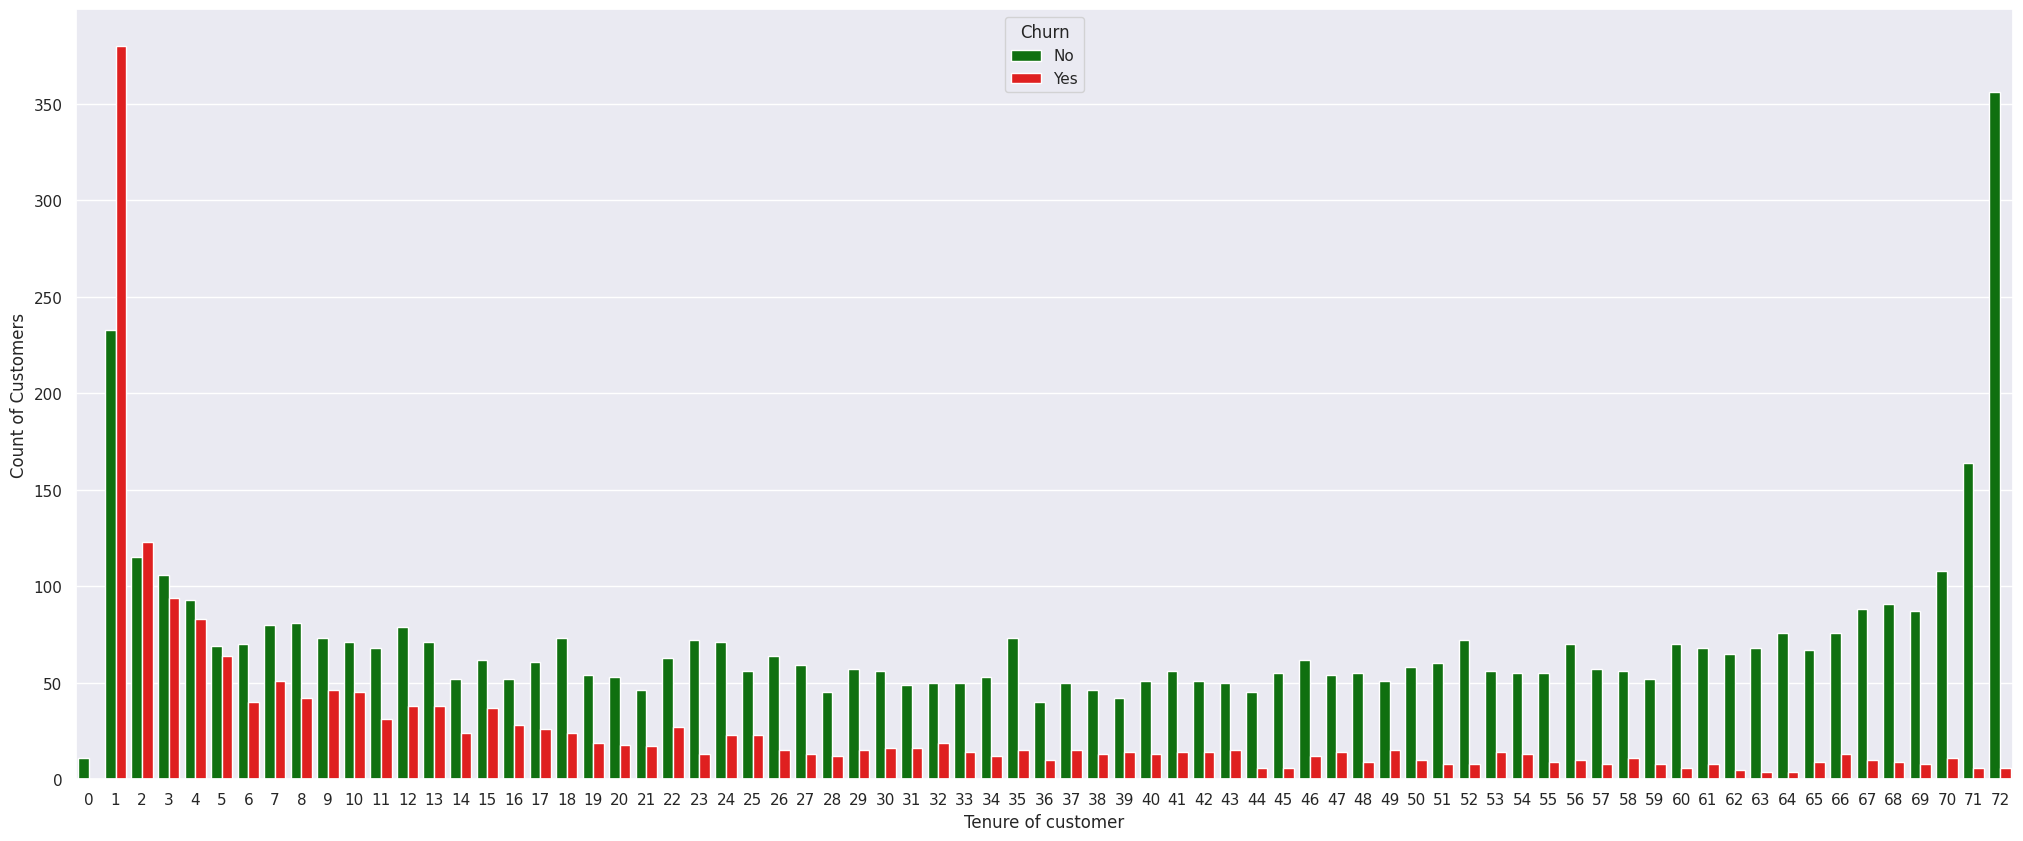

In [ ]:
# sns count barchart where tenure and  is x and churn rate is y
sns.set(rc={'figure.figsize':(25,10)})
sns.countplot(x = 'tenure', hue = 'Churn', data = df, palette = {'Yes': 'red', 'No': 'green'})
plt.ylabel('Count of Customers')
plt.xlabel('Tenure of customer')
plt.show()


**The majority of Customers with Churn happens in the first periods.**

Data Preparation

In [ ]:
# We need to drop the customer ID, a non relevant info (but storing it in a new dataframe)
df_id = df['customerID']
df.drop(['customerID'], axis=1, inplace=True)

# For the models to work, we need to set the dependent variable as a dummy, with a lambda function
df['Churn'] = df['Churn'].apply(lambda x: 0 if x == 'No' else 1 )

# TotalCharges is a numeric column. As such, we need to convert it.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now, we grab the index of all erros, so we can further investigate
erros_total_charges = list(df['TotalCharges'].loc[df['TotalCharges'].isnull()].index)

# Now we plot the errors, and it seems to match the lines where tenure is null
(df.iloc[erros_total_charges] == df.loc[df['tenure'] == 0])

# So, for this situation, we plot the monthly charges to each respective line
df['TotalCharges'].iloc[erros_total_charges] = df['MonthlyCharges'].iloc[erros_total_charges]

# Now we select all the columns which stands as objects in a list, so we can convert to a dummy
object_columns = []

for i in df.select_dtypes(include=['object']).columns:
    if i == 'Churn':
        pass
    else:
        object_columns.extend([i])


Create dummies

In [ ]:
# Now we are ready to convert
df = pd.get_dummies(df, columns=object_columns)

# At this step, we have every column to be a number. So, we convert everything to float (except churn column)
for i in df.columns:
    try:
        df[i].astype(float)
    except:
        if i == 'Churn':
            pass


Separate our DataFrame into training and test sets

In [ ]:
# First we set the X and Y (dependent and independent variables)
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y)

Test 30 machine learning models using LazyPredict

In [ ]:
# As a second step, we run the lazy predict, to a enhanced vision about the best models to fit
clf = LazyClassifier(verbose=0, ignore_warnings=True, predictions=True)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)


# Now we select the top 4, and run a GridSearch, to tune the hyperparameters
print('\n','Top 4 Models')
print(list(models.nlargest(4, columns='Accuracy').reset_index()['Model']))

# Display LazyClassifer results based on accuracy in descending order
models.sort_values(by=['Accuracy'], ascending=False)


100%|██████████| 29/29 [00:16<00:00,  1.73it/s]

[LightGBM] [Info] Number of positive: 1393, number of negative: 3889
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002508 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 710
[LightGBM] [Info] Number of data points in the train set: 5282, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.263726 -> initscore=-1.026692
[LightGBM] [Info] Start training from score -1.026692

 Top 4 Models
['AdaBoostClassifier', 'LinearSVC', 'RidgeClassifier', 'LogisticRegression']


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
AdaBoostClassifier,0.80,0.72,0.72,0.80,0.46
LinearSVC,0.80,0.72,0.72,0.79,1.01
RidgeClassifier,0.80,0.71,0.71,0.79,0.05
RidgeClassifierCV,0.80,0.71,0.71,0.79,0.11
LogisticRegression,0.80,0.72,0.72,0.79,0.11
CalibratedClassifierCV,0.80,0.72,0.72,0.79,3.64
LinearDiscriminantAnalysis,0.79,0.72,0.72,0.79,0.08
LGBMClassifier,0.79,0.71,0.71,0.79,0.23
SVC,0.79,0.70,0.70,0.78,1.71


Perform GridSearch for the top 4 models

In [ ]:
# First we instantiate the models
ada = AdaBoostClassifier()
lin_svc = LinearSVC()
ridge = RidgeClassifier()
log_reg = LogisticRegression()

# Now we plot the parameters where grid search might try to find the best match
parameters_ada = {'n_estimators':[10, 50, 250, 1000],
              'learning_rate':[0.01, 0.1]}

parameters_lin_svc = {'C':[1, 10, 100, 1000]}

parameters_ridge = {'alpha': [1, 0.1, 0.01, 0.001, 0.0001, 0] ,
                    "solver": ['svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']}

parameters_log_reg = {'penalty' : ['l1', 'l2', 'elasticnet'],
                      'multi_class': ['auto', 'ovr', 'multinomial']}

# Now we set the grid search for each model
grid_ada = GridSearchCV(ada, parameters_ada, n_jobs=-1, verbose=0)
grid_lin_svc = GridSearchCV(lin_svc, parameters_lin_svc, n_jobs=-1, verbose=0)
grid_ridge = GridSearchCV(ridge, parameters_ridge, n_jobs=-1, verbose=0)
grid_log_reg = GridSearchCV(log_reg, parameters_log_reg, n_jobs=-1, verbose=0)

# We should fit those parameters into our tests dfs
print('Running GridSearch for Adaboost...')
grid_ada.fit(X_train, y_train)
print('Running GridSearch for LinearSVC...')
grid_lin_svc.fit(X_train, y_train)
print('Running GridSearch for RidgeClassifier...')
grid_ridge.fit(X_train, y_train)
print('Running GridSearch for Logistic Regression...')
grid_log_reg.fit(X_train, y_train)

# At last, we print the best parameters for each model
best_ada = grid_ada.best_params_
print('Best parameters for Adaboost:', best_ada)
best_svc = grid_lin_svc.best_params_
print('Best parameters for Linear SVC:', best_svc)
best_ridge = grid_ridge.best_params_
print('Best parameters for Ridge Classifier:', best_ridge)
best_log = grid_log_reg.best_params_
print('Best parameters for Logistic Regression:', best_log)

# Now we run the best parameters for each model
ada_model = AdaBoostClassifier(n_estimators=best_ada['n_estimators'],
              learning_rate=best_ada['learning_rate'])
ada_model.fit(X_train, y_train)

svc_model = LinearSVC(C=best_svc['C'])
svc_model.fit(X_train, y_train)

ridge_model = RidgeClassifier(alpha=best_ridge['alpha'], solver=best_ridge['solver'])
ridge_model.fit(X_train, y_train)

log_model = LogisticRegression(penalty=best_log['penalty'], multi_class=best_log['multi_class'])
log_model.fit(X_train, y_train);

Running GridSearch for Adaboost...
Running GridSearch for LinearSVC...
Running GridSearch for RidgeClassifier...
Running GridSearch for Logistic Regression...
Best parameters for Adaboost: {'learning_rate': 0.1, 'n_estimators': 1000}
Best parameters for Linear SVC: {'C': 100}
Best parameters for Ridge Classifier: {'alpha': 0.1, 'solver': 'svd'}
Best parameters for Logistic Regression: {'multi_class': 'multinomial', 'penalty': 'l2'}


Now we can make predictions using the best models with the best parameters

In [ ]:
# Predict all the models
ada_predict = ada_model.predict(X_test)
svc_predict = svc_model.predict(X_test)
ridge_predict = ridge_model.predict(X_test)
log_predict = log_model.predict(X_test)

# Grab the best AUC Score
auc_score = {'Adaboost': roc_auc_score(y_test, ada_predict),
             'Linear SVC': roc_auc_score(y_test, svc_predict),
             'Ridge Classifier': roc_auc_score(y_test, ridge_predict),
             'Logistic Regression': roc_auc_score(y_test, log_predict)}

# Obtain the highest value in the auc_score dictionary
best = max(auc_score.items(), key = lambda x: x[1])
print(f'The best performance model is {best[0]}, with an AUC Score of {best[1]}.')

The best performance model is Adaboost, with an AUC Score of 0.7280498970016023!


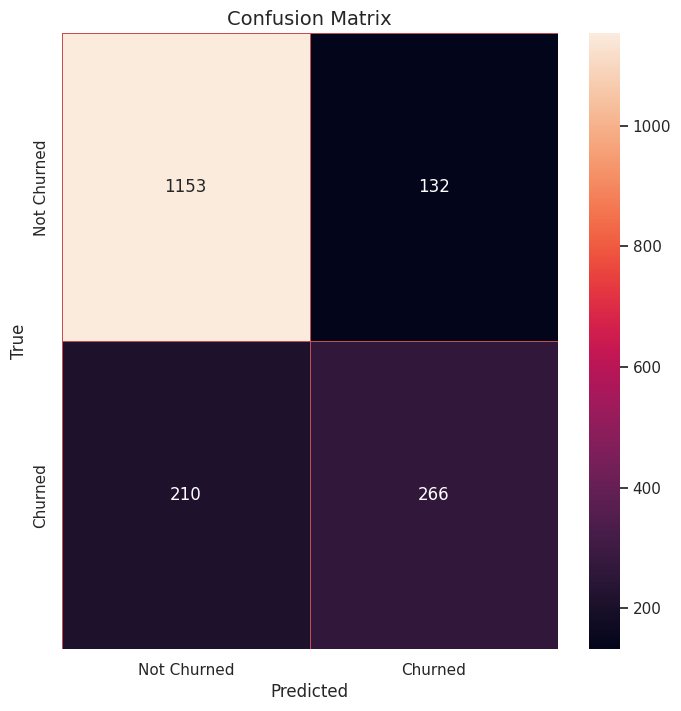

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1285
           1       0.67      0.56      0.61       476

    accuracy                           0.81      1761
   macro avg       0.76      0.73      0.74      1761
weighted avg       0.80      0.81      0.80      1761



In [ ]:
# Plot confusion matrix based on ada_predict with precision, recall, f1-score, support chart

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, ada_predict)

# Create a labels list
labels = ['Not Churned', 'Churned']

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cm, annot=True, linewidth=0.6, linecolor="r", fmt=".0f", ax=ax)

# Set labels, title and ticks
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Confusion Matrix", fontsize=14)
plt.show()

# Print the classification report
print(classification_report(y_test, ada_predict))
